<a href="https://colab.research.google.com/github/nilesh426/CSL701-42_Machine-Learning-Lab/blob/main/Experiments/ML_EXP5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Machine Learning Experiment No. 05


Name: Nilesh Ashok Sawant
Roll No: CE42
Batch: CE3

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

from sklearn.ensemble import BaggingClassifier

In [41]:
columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# Load the dataset

from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Read the uploaded CSV file into a DataFrame
  df = pd.read_csv(
      fn,
      header=0, # Changed from header=None to header=0 to correctly read the file's header
      names=columns
  )

# Display first 5 records

print("First 5 Records:")
print(df.head())

# Dataset shape

print("\nDataset Shape:")
print(df.shape)

# Data types

print("\nData Types:")
print(df.dtypes)

# Descriptive statistics

print("\nDescriptive Statistics:")
print(df.describe())

Saving diabetes_data.csv to diabetes_data (3).csv
User uploaded file "diabetes_data (3).csv" with length 25706 bytes
First 5 Records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness          

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

2.1 Count and Percentage of Each Class

In [42]:
class_count = df['Outcome'].value_counts()

class_percentage = (
    df['Outcome'].value_counts(normalize=True) * 100
)

print("Class Count:")
print(class_count)

print("\nClass Percentage:")
print(class_percentage)

Class Count:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


2.2 Class Balance Bar Chart

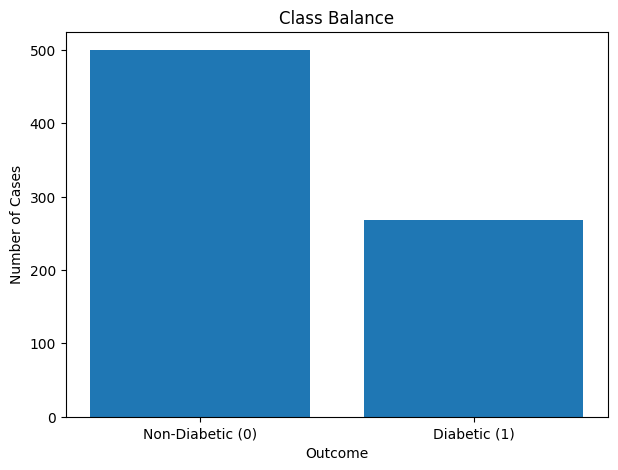

In [43]:
plt.figure(figsize=(7, 5))

plt.bar(
    ['Non-Diabetic (0)', 'Diabetic (1)'],
    [class_count[0], class_count[1]]
)

plt.title('Class Balance')
plt.xlabel('Outcome')
plt.ylabel('Number of Cases')

plt.show()

2.3 Age vs Glucose Scatter Plot

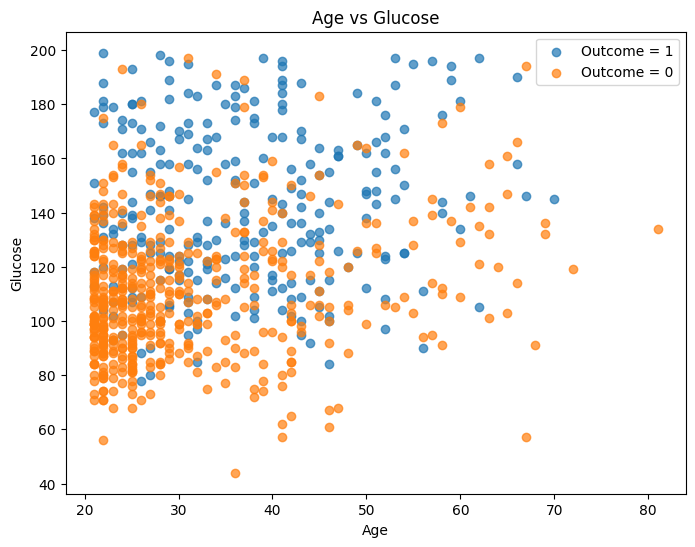

In [44]:
plt.figure(figsize=(8, 6))

for outcome in df['Outcome'].unique():
    subset = df[df['Outcome'] == outcome]

    plt.scatter(
        subset['Age'],
        subset['Glucose'],
        label=f'Outcome = {outcome}',
        alpha=0.7
    )

plt.title('Age vs Glucose')
plt.xlabel('Age')
plt.ylabel('Glucose')

plt.legend()

plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [45]:
# Features where 0 is physically impossible

invalid_zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# Count zeros before replacement

print("Number of Invalid Zero Values:")

for column in invalid_zero_columns:
    print(column, ":", (df[column] == 0).sum())

df[invalid_zero_columns] = df[invalid_zero_columns].replace(
    0,
    np.nan
)

print("\nMissing Values After Replacing Zeros:")

print(df.isnull().sum())

for column in invalid_zero_columns:
    df[column] = df[column].fillna(df[column].mean())

print("\nMissing Values After Imputation:")

print(df.isnull().sum())

Number of Invalid Zero Values:
Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0

Missing Values After Replacing Zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing Values After Imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [46]:
# Feature matrix

X = df.iloc[:, :8]

# Target vector

y = df.iloc[:, 8]

# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("\ny_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

print("\nOriginal Dataset Class Proportion:")
print(y.value_counts(normalize=True))

print("\nTraining Dataset Class Proportion:")
print(y_train.value_counts(normalize=True))

print("\nTesting Dataset Class Proportion:")
print(y_test.value_counts(normalize=True))

X_train Shape: (614, 8)
X_test Shape : (154, 8)

y_train Shape: (614,)
y_test Shape : (154,)

Original Dataset Class Proportion:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Training Dataset Class Proportion:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing Dataset Class Proportion:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [47]:
def get_bootstrap_sample(X, y):

    n_samples = len(X)

    # Generate random indices with replacement

    bootstrap_indices = np.random.choice(
        n_samples,
        size=n_samples,
        replace=True
    )

    # Convert to NumPy arrays for indexing

    X_array = np.array(X)
    y_array = np.array(y)

    # Create bootstrap samples

    X_bootstrap = X_array[bootstrap_indices]

    y_bootstrap = y_array[bootstrap_indices]

    return X_bootstrap, y_bootstrap, bootstrap_indices

In [48]:
X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

print("Original Training Size:")
print(len(X_train))

print("\nBootstrap Sample Size:")
print(len(X_bootstrap))

unique_indices = np.unique(bootstrap_indices)

duplicated_indices = []

for index in unique_indices:
    if np.sum(bootstrap_indices == index) > 1:
        duplicated_indices.append(int(index))

omitted_indices = np.setdiff1d(
    np.arange(len(X_train)),
    unique_indices
)

print("\nNumber of Duplicated Indices:")
print(len(duplicated_indices))

print("\nDuplicated Indices:")

for i in range(0, len(duplicated_indices), 15):
    print(*duplicated_indices[i:i+15])


print("\nNumber of Omitted (OOB) Indices:")
print(len(omitted_indices))

print("\nOmitted Indices:")

for i in range(0, len(omitted_indices), 15):
    print(
        *[int(x) for x in omitted_indices[i:i+15]]
    )

Original Training Size:
614

Bootstrap Sample Size:
614

Number of Duplicated Indices:
171

Duplicated Indices:
2 11 17 20 23 24 26 29 33 43 47 49 51 53 59
60 61 62 63 67 75 76 77 79 83 84 89 93 95 97
104 107 112 117 122 126 128 129 130 131 132 133 134 135 136
139 140 141 146 148 149 155 158 164 165 168 172 175 177 181
183 184 188 189 191 199 203 206 211 228 230 232 242 246 248
252 253 255 256 258 260 269 274 275 289 293 296 304 306 307
311 315 316 321 323 325 328 331 337 348 354 357 360 365 373
383 384 389 391 392 396 398 405 406 408 412 414 416 417 420
428 437 447 449 452 456 462 464 469 470 475 478 481 494 504
505 506 507 508 512 513 524 525 529 534 540 541 547 548 551
552 556 557 559 561 563 564 566 574 576 577 582 584 593 594
595 600 601 605 607 612

Number of Omitted (OOB) Indices:
230

Omitted Indices:
4 8 9 10 12 13 16 18 21 25 28 30 38 40 41
42 48 50 52 55 56 57 64 68 69 70 74 82 85 86
87 88 90 94 101 102 106 108 115 116 118 119 121 124 125
127 143 145 147 152 160 167 169 170 

#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [49]:
# Empty list to store Decision Trees

ensemble = []

# Number of bootstrap iterations

B = 50

# Convert training data to NumPy arrays

X_train_array = np.array(X_train)
y_train_array = np.array(y_train)

In [50]:
# Train B Decision Trees

for i in range(B):

    # Generate bootstrap sample

    X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
        X_train_array,
        y_train_array
    )

    # Create fully grown Decision Tree

    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=i
    )

    # Train model

    model.fit(
        X_bootstrap,
        y_bootstrap
    )

    # Add model to ensemble

    ensemble.append(model)

print("Number of Decision Trees in Ensemble:", len(ensemble))

Number of Decision Trees in Ensemble: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [51]:
def custom_bagging_predict(ensemble, X_test):

    # Collect predictions from all models

    predictions = []

    for model in ensemble:
        prediction = model.predict(X_test)
        predictions.append(prediction)

    # Convert predictions to NumPy array

    predictions = np.array(predictions)

    # Majority voting

    final_predictions = []

    for i in range(predictions.shape[1]):

        votes = predictions[:, i]

        # Count votes

        count_0 = np.sum(votes == 0)
        count_1 = np.sum(votes == 1)

        # Select majority class

        if count_1 > count_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)

In [52]:
X_test_array = np.array(X_test)

bagging_predictions = custom_bagging_predict(
    ensemble,
    X_test_array
)

print("Custom Bagging Predictions:")

print(bagging_predictions)

Custom Bagging Predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1 0
 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0
 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 1
 0 0 0 0 1 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [53]:
single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(
    X_train,
    y_train
)

single_tree_predictions = single_tree.predict(
    X_test
)

bagging_predictions = custom_bagging_predict(
    ensemble,
    X_test_array
)

single_tree_cm = confusion_matrix(
    y_test,
    single_tree_predictions
)

bagging_cm = confusion_matrix(
    y_test,
    bagging_predictions
)

print("Single Decision Tree Confusion Matrix:")
print(single_tree_cm)

print("\nCustom Bagging Confusion Matrix:")
print(bagging_cm)

single_tree_accuracy = accuracy_score(
    y_test,
    single_tree_predictions
)

single_tree_precision = precision_score(
    y_test,
    single_tree_predictions
)

single_tree_recall = recall_score(
    y_test,
    single_tree_predictions
)

single_tree_f1 = f1_score(
    y_test,
    single_tree_predictions
)

print("\nSINGLE DECISION TREE PERFORMANCE")

print("Accuracy :", single_tree_accuracy)
print("Precision:", single_tree_precision)
print("Recall   :", single_tree_recall)
print("F1 Score :", single_tree_f1)

bagging_accuracy = accuracy_score(
    y_test,
    bagging_predictions
)

bagging_precision = precision_score(
    y_test,
    bagging_predictions
)

bagging_recall = recall_score(
    y_test,
    bagging_predictions
)

bagging_f1 = f1_score(
    y_test,
    bagging_predictions
)

print("\nCUSTOM BAGGING PERFORMANCE")

print("Accuracy :", bagging_accuracy)
print("Precision:", bagging_precision)
print("Recall   :", bagging_recall)
print("F1 Score :", bagging_f1)

comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Single Decision Tree': [
        single_tree_accuracy,
        single_tree_precision,
        single_tree_recall,
        single_tree_f1
    ],

    'Custom Bagging': [
        bagging_accuracy,
        bagging_precision,
        bagging_recall,
        bagging_f1
    ]
})

print("\n")
print(comparison)

Single Decision Tree Confusion Matrix:
[[87 13]
 [16 38]]

Custom Bagging Confusion Matrix:
[[93  7]
 [11 43]]

SINGLE DECISION TREE PERFORMANCE
Accuracy : 0.8116883116883117
Precision: 0.7450980392156863
Recall   : 0.7037037037037037
F1 Score : 0.7238095238095238

CUSTOM BAGGING PERFORMANCE
Accuracy : 0.8831168831168831
Precision: 0.86
Recall   : 0.7962962962962963
F1 Score : 0.8269230769230769


      Metric  Single Decision Tree  Custom Bagging
0   Accuracy              0.811688        0.883117
1  Precision              0.745098        0.860000
2     Recall              0.703704        0.796296
3   F1 Score              0.723810        0.826923


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Single Decision Tree AUC: 0.7868518518518519
Custom Bagging AUC: 0.9541666666666666


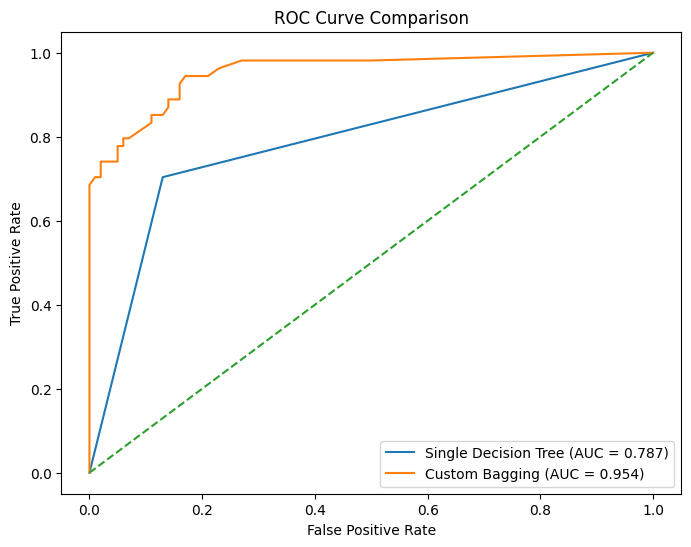

In [54]:
def custom_bagging_predict_proba(ensemble, X_test):

    probabilities = []

    for model in ensemble:

        model_probabilities = model.predict_proba(X_test)

        probabilities.append(
            model_probabilities
        )

    probabilities = np.array(probabilities)

    # Average probabilities from all models

    average_probabilities = np.mean(
        probabilities,
        axis=0
    )

    return average_probabilities

bagging_probabilities = custom_bagging_predict_proba(
    ensemble,
    X_test_array
)

bagging_probability_class_1 = bagging_probabilities[:, 1]

single_tree_probabilities = single_tree.predict_proba(
    X_test
)

single_tree_probability_class_1 = single_tree_probabilities[:, 1]

fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    single_tree_probability_class_1
)

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    bagging_probability_class_1
)

single_tree_auc = roc_auc_score(
    y_test,
    single_tree_probability_class_1
)

bagging_auc = roc_auc_score(
    y_test,
    bagging_probability_class_1
)

print("Single Decision Tree AUC:", single_tree_auc)

print("Custom Bagging AUC:", bagging_auc)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f'Single Decision Tree (AUC = {single_tree_auc:.3f})'
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f'Custom Bagging (AUC = {bagging_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [55]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Create Scikit-Learn Bagging Classifier

sklearn_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=50,
    random_state=42
)

# Train the model

sklearn_bagging.fit(X_train, y_train)

# Make predictions on the test set

sklearn_bagging_predictions = sklearn_bagging.predict(X_test)

# Calculate accuracy

sklearn_bagging_accuracy = accuracy_score(
    y_test,
    sklearn_bagging_predictions
)

# Calculate confusion matrix

sklearn_bagging_cm = confusion_matrix(
    y_test,
    sklearn_bagging_predictions
)

# Print Custom Bagging Results

print("CUSTOM BAGGING RESULTS")
print("-" * 40)

print("Accuracy:", bagging_accuracy)

print("\nConfusion Matrix:")
print(bagging_cm)


# Print Scikit-Learn Bagging Results

print("\n" + "=" * 50)

print("SCIKIT-LEARN BAGGING RESULTS")
print("-" * 40)

print("Accuracy:", sklearn_bagging_accuracy)

print("\nConfusion Matrix:")
print(sklearn_bagging_cm)


# Final comparison table

comparison = pd.DataFrame({
    'Model': [
        'Custom Bagging',
        'Scikit-Learn Bagging'
    ],

    'Accuracy': [
        bagging_accuracy,
        sklearn_bagging_accuracy
    ]
})

print("\n" + "=" * 50)
print("FINAL COMPARISON")

print(comparison.to_string(index=False))

CUSTOM BAGGING RESULTS
----------------------------------------
Accuracy: 0.8831168831168831

Confusion Matrix:
[[93  7]
 [11 43]]

SCIKIT-LEARN BAGGING RESULTS
----------------------------------------
Accuracy: 0.8831168831168831

Confusion Matrix:
[[91  9]
 [ 9 45]]

FINAL COMPARISON
               Model  Accuracy
      Custom Bagging  0.883117
Scikit-Learn Bagging  0.883117


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?